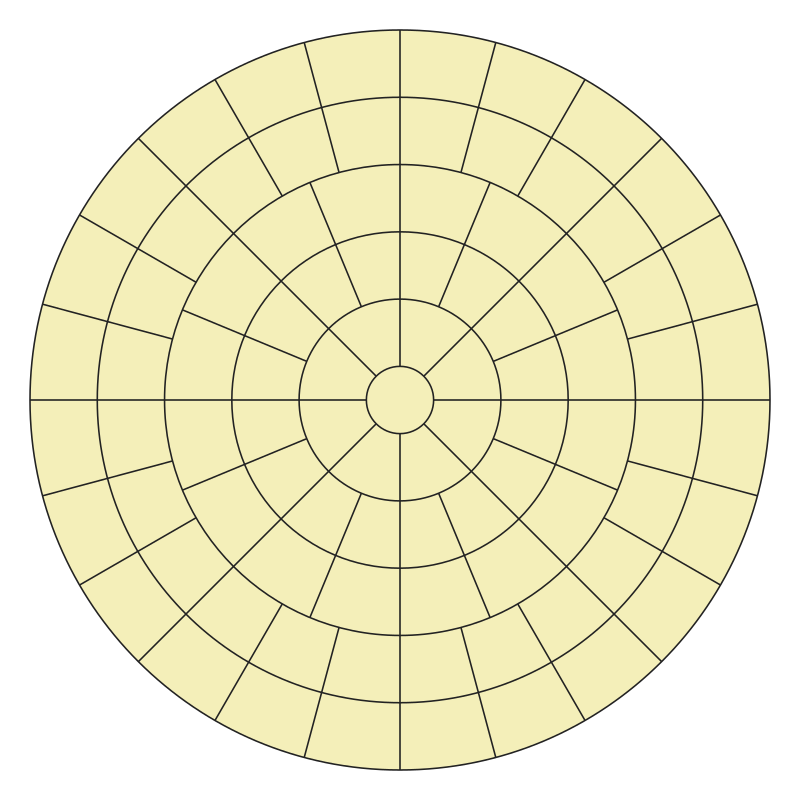

In [1]:
import math
from IPython.display import SVG, display


class KaleidoBoardSVG:
    def __init__(
        self,
        background_color="#ffffff",
        board_fill="#f2edb8",
        board_stroke="#222222",
        board_size=800,
        stroke_width=2.0,
        margin=40,
    ):
        self.background_color = background_color
        self.board_fill = board_fill
        self.board_stroke = board_stroke
        self.board_size = board_size
        self.stroke_width = stroke_width
        self.margin = margin
        self.rotation_offset_deg = -22.5
        self.cx = board_size / 2
        self.cy = board_size / 2

        # 실제 논리 반지름 경계
        # 0번째 링 = 중심원 = 반지름 0.5
        # 이후 1씩 증가
        self.r_boundaries = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

        # 각 링의 분할 수
        # index 0: 중앙 원(분할 없음)
        # index 1: 8칸
        # index 2: 16칸
        # index 3: 16칸
        # index 4: 24칸
        # index 5: 24칸
        self.ring_sectors = {
            1: 8,
            2: 16,
            3: 16,
            4: 24,
            5: 24,
        }

        self.max_r = self.r_boundaries[-1]
        self.scale = (board_size / 2 - margin) / self.max_r

    def scaled_r(self, r):
        return r * self.scale

    def polar_to_cart(self, r, deg):
        rad = math.radians(deg)
        rr = self.scaled_r(r)
        x = self.cx + rr * math.cos(rad)
        y = self.cy + rr * math.sin(rad)
        return x, y

    def svg_header(self):
        s = self.board_size
        return (
            f'<svg xmlns="http://www.w3.org/2000/svg" '
            f'width="{s}" height="{s}" viewBox="0 0 {s} {s}">'
        )

    def svg_background(self):
        s = self.board_size
        return f'<rect x="0" y="0" width="{s}" height="{s}" fill="{self.background_color}" />'

    def draw_board_base(self):
        outer_r = self.scaled_r(self.max_r)
        return (
            f'<circle cx="{self.cx}" cy="{self.cy}" r="{outer_r}" '
            f'fill="{self.board_fill}" stroke="{self.board_stroke}" '
            f'stroke-width="{self.stroke_width}" />'
        )

    def draw_concentric_circles(self):
        parts = []
        for r in self.r_boundaries[:-1]:
            parts.append(
                f'<circle cx="{self.cx}" cy="{self.cy}" r="{self.scaled_r(r)}" '
                f'fill="none" stroke="{self.board_stroke}" '
                f'stroke-width="{self.stroke_width}" />'
            )
        return "\n".join(parts)

    def draw_radial_lines_for_ring(self, ring_index, start_angle=-90):
        """
        ring_index번째 링의 경계선만 그림.
        중앙 원(0번째 링)은 방사선 없음.
        ring_index=1 이면 반지름 0.5~1.5 사이에만 방사선 8개.
        """
        if ring_index == 0:
            return ""

        n = self.ring_sectors[ring_index]
        r_in = self.r_boundaries[ring_index - 1]
        r_out = self.r_boundaries[ring_index]

        parts = []
        angle_step = 360 / n

        for i in range(n):
            deg = start_angle + i * angle_step
            x1, y1 = self.polar_to_cart(r_in, deg)
            x2, y2 = self.polar_to_cart(r_out, deg)
            parts.append(
                f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" '
                f'stroke="{self.board_stroke}" stroke-width="{self.stroke_width}" />'
            )

        return "\n".join(parts)

    def render(self):
        parts = [
            self.svg_header(),
            self.svg_background(),
            '<g id="board">',
            self.draw_board_base(),
            self.draw_concentric_circles(),
        ]

        # 각 링별 분할선
        for ring_index in range(1, 6):
            parts.append(f'<g id="ring-{ring_index}-radials">')
            parts.append(self.draw_radial_lines_for_ring(ring_index))
            parts.append("</g>")

        parts += [
            "</g>",
            "</svg>"
        ]
        return "\n".join(parts)


# 사용 예시
board = KaleidoBoardSVG(
    background_color="#ffffff",
    board_fill="#f4efb9",
    board_stroke="#222222",
    board_size=800,
    stroke_width=1.6,
    margin=30,
)

svg_text = board.render()
display(SVG(svg_text))

# 저장
with open("empty_kaleido_board.svg", "w", encoding="utf-8") as f:
    f.write(svg_text)

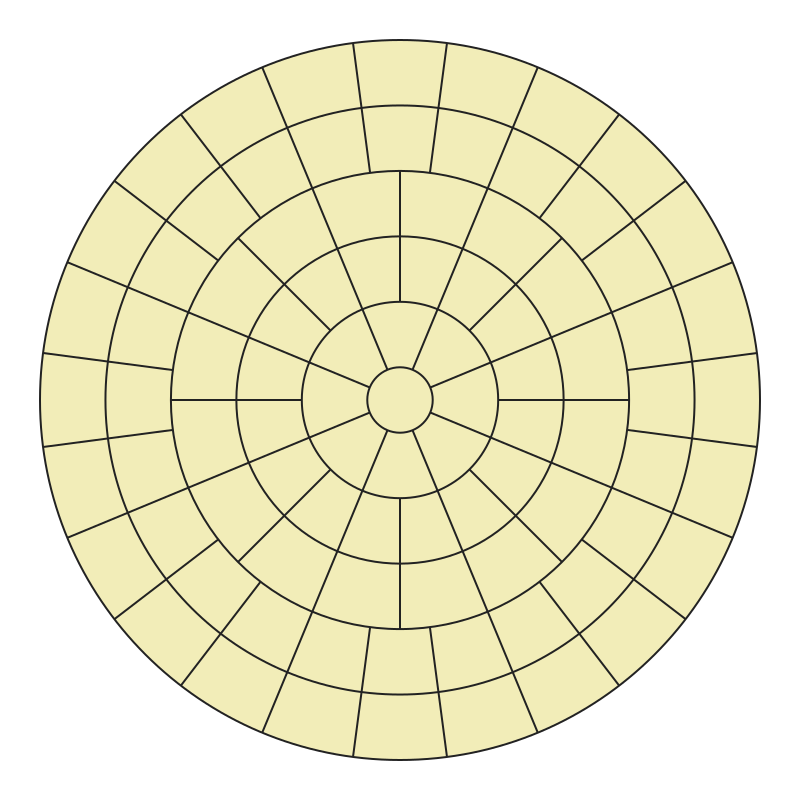

In [2]:
import math
from IPython.display import SVG, display


class KaleidoBoardSVG:
    def __init__(
        self,
        background_color="#ffffff",
        board_fill="#f2edb8",
        palace_fill="#f2edb8",
        home_fill="#f2edb8",
        board_stroke="#222222",
        board_size=800,
        stroke_width=2.0,
        margin=40,
    ):
        self.background_color = background_color
        self.board_fill = board_fill
        self.board_stroke = board_stroke
        self.board_size = board_size
        self.stroke_width = stroke_width
        self.margin = margin

        self.cx = board_size / 2
        self.cy = board_size / 2

        self.r_boundaries = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
        self.ring_sectors = {
            1: 8,
            2: 16,
            3: 16,
            4: 24,
            5: 24,
        }

        self.max_r = self.r_boundaries[-1]
        self.scale = (board_size / 2 - margin) / self.max_r

        # 실제 원 게임과 맞추기 위한 회전 보정
        self.rotation_offset_deg = -22.5

    def scaled_r(self, r):
        return r * self.scale

    def polar_to_cart(self, r, deg):
        rad = math.radians(deg)
        rr = self.scaled_r(r)
        x = self.cx + rr * math.cos(rad)
        y = self.cy + rr * math.sin(rad)
        return x, y

    def svg_header(self):
        s = self.board_size
        return f'<svg xmlns="http://www.w3.org/2000/svg" width="{s}" height="{s}" viewBox="0 0 {s} {s}">'

    def svg_background(self):
        s = self.board_size
        return f'<rect x="0" y="0" width="{s}" height="{s}" fill="{self.background_color}" />'

    def draw_board_base(self):
        outer_r = self.scaled_r(self.max_r)
        return (
            f'<circle cx="{self.cx}" cy="{self.cy}" r="{outer_r}" '
            f'fill="{self.board_fill}" stroke="{self.board_stroke}" '
            f'stroke-width="{self.stroke_width}" />'
        )

    def draw_concentric_circles(self):
        parts = []
        for r in self.r_boundaries[:-1]:
            parts.append(
                f'<circle cx="{self.cx}" cy="{self.cy}" r="{self.scaled_r(r)}" '
                f'fill="none" stroke="{self.board_stroke}" '
                f'stroke-width="{self.stroke_width}" />'
            )
        return "\n".join(parts)

    def draw_radial_lines_for_ring(self, ring_index, start_angle=-90):
        if ring_index == 0:
            return ""

        n = self.ring_sectors[ring_index]
        r_in = self.r_boundaries[ring_index - 1]
        r_out = self.r_boundaries[ring_index]
        angle_step = 360 / n

        parts = []
        for i in range(n):
            deg = start_angle + self.rotation_offset_deg + i * angle_step
            x1, y1 = self.polar_to_cart(r_in, deg)
            x2, y2 = self.polar_to_cart(r_out, deg)
            parts.append(
                f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" '
                f'stroke="{self.board_stroke}" stroke-width="{self.stroke_width}" />'
            )
        return "\n".join(parts)

    def render(self):
        parts = [
            self.svg_header(),
            self.svg_background(),
            '<g id="board">',
            self.draw_board_base(),
            self.draw_concentric_circles(),
        ]

        for ring_index in range(1, 6):
            parts.append(self.draw_radial_lines_for_ring(ring_index))

        parts += ["</g>", "</svg>"]
        return "\n".join(parts)


board = KaleidoBoardSVG()
display(SVG(board.render()))

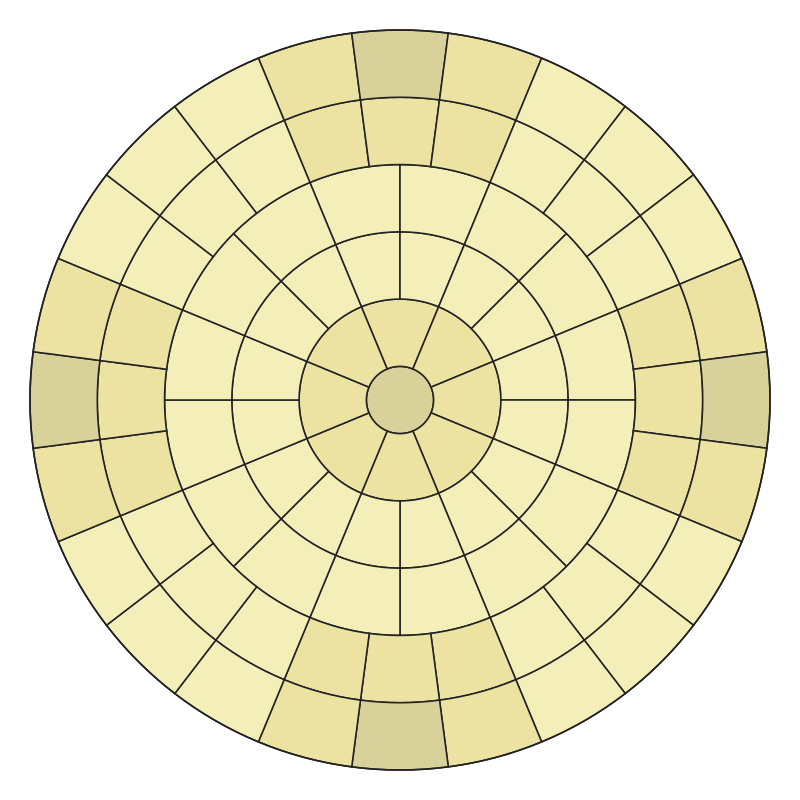

In [3]:
import math
from IPython.display import SVG, display


class KaleidoBoardSVG:
    def __init__(
        self,
        background_color="#ffffff",
        board_fill="#f2edb8",
        palace_fill="#efe7aa",
        home_fill="#ddd59a",
        board_stroke="#222222",
        board_size=800,
        stroke_width=2.0,
        margin=40,
    ):
        self.background_color = background_color
        self.board_fill = board_fill
        self.palace_fill = palace_fill
        self.home_fill = home_fill
        self.board_stroke = board_stroke
        self.board_size = board_size
        self.stroke_width = stroke_width
        self.margin = margin

        self.cx = board_size / 2
        self.cy = board_size / 2

        # 링 경계: 0번째 링 반지름 0.5, 이후 1씩 증가
        self.r_boundaries = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

        # 각 링의 분할 수
        self.ring_sectors = {
            1: 8,
            2: 16,
            3: 16,
            4: 24,
            5: 24,
        }

        self.max_r = self.r_boundaries[-1]
        self.scale = (board_size / 2 - margin) / self.max_r

        # 원 게임과 각도 맞추기
        self.rotation_offset_deg = -22.5

        # ===== 특수 칸 지정 =====
        # 중앙 왕자리
        self.throne_cell = "00"

        # 궁성: 중앙 둘레의 8칸 전체+변두리 4개 홈 주변 각 5칸
        self.palace_cells = {
            (1, 0), (1, 1), (1, 2), (1, 3),(1, 4), (1, 5), (1, 6), (1, 7),
            (4, 0), (4, 1), (4, 2), (5, 0), (5, 2),
            (4, 6), (4, 7), (4, 8), (5, 6), (5, 8),
            (4, 12), (4, 13), (4, 14), (5, 12), (5, 14),
            (4, 18), (4, 19), (4, 20), (5, 18), (5, 20)
        }
        # 홈칸 5개: 중앙 왕자리를 제외한 4개만 표시
        self.home_cells = {
            (5, 1),  # 위
            (5, 7),   # 우
            (5, 13),   # 히
            (5, 19),  # 좌
        }

    def scaled_r(self, r):
        return r * self.scale

    def polar_to_cart(self, r, deg):
        rad = math.radians(deg)
        rr = self.scaled_r(r)
        x = self.cx + rr * math.cos(rad)
        y = self.cy + rr * math.sin(rad)
        return x, y

    def svg_header(self):
        s = self.board_size
        return (
            f'<svg xmlns="http://www.w3.org/2000/svg" '
            f'width="{s}" height="{s}" viewBox="0 0 {s} {s}">'
        )

    def svg_background(self):
        s = self.board_size
        return f'<rect x="0" y="0" width="{s}" height="{s}" fill="{self.background_color}" />'

    def outer_border(self):
        outer_r = self.scaled_r(self.max_r)
        return (
            f'<circle cx="{self.cx}" cy="{self.cy}" r="{outer_r}" '
            f'fill="none" stroke="{self.board_stroke}" '
            f'stroke-width="{self.stroke_width}" />'
        )

    def annular_sector_path(self, r_in, r_out, a0, a1):
        x1, y1 = self.polar_to_cart(r_in, a0)
        x2, y2 = self.polar_to_cart(r_out, a0)
        x3, y3 = self.polar_to_cart(r_out, a1)
        x4, y4 = self.polar_to_cart(r_in, a1)

        large_arc = 1 if ((a1 - a0) % 360) > 180 else 0
        r_out_px = self.scaled_r(r_out)
        r_in_px = self.scaled_r(r_in)

        return (
            f"M {x1:.4f},{y1:.4f} "
            f"L {x2:.4f},{y2:.4f} "
            f"A {r_out_px:.4f},{r_out_px:.4f} 0 {large_arc} 1 {x3:.4f},{y3:.4f} "
            f"L {x4:.4f},{y4:.4f} "
            f"A {r_in_px:.4f},{r_in_px:.4f} 0 {large_arc} 0 {x1:.4f},{y1:.4f} Z"
        )

    def cell_fill(self, ring_index=None, sector=None, is_center=False):
        if is_center:
            return self.home_fill
        if (ring_index, sector) in self.home_cells:
            return self.home_fill
        if (ring_index, sector) in self.palace_cells:
            return self.palace_fill
        return self.board_fill

    def draw_center_cell(self):
        r = self.scaled_r(self.r_boundaries[0])
        fill = self.cell_fill(is_center=True)
        return (
            f'<circle cx="{self.cx}" cy="{self.cy}" r="{r}" '
            f'fill="{fill}" stroke="{self.board_stroke}" '
            f'stroke-width="{self.stroke_width}" />'
        )

    def draw_ring_cells(self, ring_index, start_angle=-90):
        n = self.ring_sectors[ring_index]
        r_in = self.r_boundaries[ring_index - 1]
        r_out = self.r_boundaries[ring_index]
        angle_step = 360 / n

        parts = []
        for sector in range(n):
            a0 = start_angle + self.rotation_offset_deg + sector * angle_step
            a1 = a0 + angle_step
            d = self.annular_sector_path(r_in, r_out, a0, a1)
            fill = self.cell_fill(ring_index, sector)

            parts.append(
                f'<path d="{d}" fill="{fill}" '
                f'stroke="{self.board_stroke}" '
                f'stroke-width="{self.stroke_width}" />'
            )
        return "\n".join(parts)

    def render(self):
        parts = [
            self.svg_header(),
            self.svg_background(),
            '<g id="board-cells">',
            self.draw_center_cell(),
        ]

        for ring_index in range(1, 6):
            parts.append(self.draw_ring_cells(ring_index))

        parts += [
            "</g>",
            '<g id="board-border">',
            self.outer_border(),
            "</g>",
            "</svg>",
        ]
        return "\n".join(parts)


# 사용 예시
board = KaleidoBoardSVG(
    background_color="#ffffff",
    board_fill="#f4efb9",
    palace_fill="#ece2a2",
    home_fill="#d9d19a",
    board_stroke="#222222",
    board_size=800,
    stroke_width=1.6,
    margin=30,
)

svg_text = board.render()
display(SVG(svg_text))

with open("empty_kaleido_board_colored.svg", "w", encoding="utf-8") as f:
    f.write(svg_text)

In [4]:
import math
from IPython.display import SVG, display


class KaleidoBoardSVG:
    def __init__(
        self,
        background_color="#ffffff",
        board_fill="#f2edb8",
        palace_fill="#efe7aa",
        home_fill="#ddd59a",
        board_stroke="#222222",
        board_size=800,
        stroke_width=2.0,
        margin=40,
    ):
        self.background_color = background_color
        self.board_fill = board_fill
        self.palace_fill = palace_fill
        self.home_fill = home_fill
        self.board_stroke = board_stroke
        self.board_size = board_size
        self.stroke_width = stroke_width
        self.margin = margin

        self.cx = board_size / 2
        self.cy = board_size / 2

        # 링 경계: 0번째 링 반지름 0.5, 이후 1씩 증가
        self.r_boundaries = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

        # 각 링의 분할 수
        self.ring_sectors = {
            1: 8,
            2: 16,
            3: 16,
            4: 24,
            5: 24,
        }

        self.max_r = self.r_boundaries[-1]
        self.scale = (board_size / 2 - margin) / self.max_r

        # 원 게임과 각도 맞추기
        self.rotation_offset_deg = -22.5

        # 궁성
        self.palace_cells = {
            (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7),
            (4, 0), (4, 1), (4, 2), (5, 0), (5, 2),
            (4, 6), (4, 7), (4, 8), (5, 6), (5, 8),
            (4, 12), (4, 13), (4, 14), (5, 12), (5, 14),
            (4, 18), (4, 19), (4, 20), (5, 18), (5, 20)
        }

        # 홈칸 4개 + 중앙
        self.home_cells = {
            (5, 1),
            (5, 7),
            (5, 13),
            (5, 19),
        }

        # 좌표 문자 -> 링 / local index
        self.letter_to_ring_local = {
            "G": (1, 0),
            "H": (2, 0), "F": (2, 1),
            "I": (3, 0), "E": (3, 1),
            "J": (4, 0), "A": (4, 1), "D": (4, 2),
            "K": (5, 0), "B": (5, 1), "C": (5, 2),
        }

        self.ring_to_letters = {
            1: ["G"],
            2: ["H", "F"],
            3: ["I", "E"],
            4: ["J", "A", "D"],
            5: ["K", "B", "C"],
        }

    def scaled_r(self, r):
        return r * self.scale

    def polar_to_cart(self, r, deg):
        rad = math.radians(deg)
        rr = self.scaled_r(r)
        x = self.cx + rr * math.cos(rad)
        y = self.cy + rr * math.sin(rad)
        return x, y

    def svg_header(self):
        s = self.board_size
        return (
            f'<svg xmlns="http://www.w3.org/2000/svg" '
            f'width="{s}" height="{s}" viewBox="0 0 {s} {s}">'
        )

    def svg_background(self):
        s = self.board_size
        return f'<rect x="0" y="0" width="{s}" height="{s}" fill="{self.background_color}" />'

    def outer_border(self):
        outer_r = self.scaled_r(self.max_r)
        return (
            f'<circle cx="{self.cx}" cy="{self.cy}" r="{outer_r}" '
            f'fill="none" stroke="{self.board_stroke}" '
            f'stroke-width="{self.stroke_width}" />'
        )

    def annular_sector_path(self, r_in, r_out, a0, a1):
        x1, y1 = self.polar_to_cart(r_in, a0)
        x2, y2 = self.polar_to_cart(r_out, a0)
        x3, y3 = self.polar_to_cart(r_out, a1)
        x4, y4 = self.polar_to_cart(r_in, a1)

        large_arc = 1 if ((a1 - a0) % 360) > 180 else 0
        r_out_px = self.scaled_r(r_out)
        r_in_px = self.scaled_r(r_in)

        return (
            f"M {x1:.4f},{y1:.4f} "
            f"L {x2:.4f},{y2:.4f} "
            f"A {r_out_px:.4f},{r_out_px:.4f} 0 {large_arc} 1 {x3:.4f},{y3:.4f} "
            f"L {x4:.4f},{y4:.4f} "
            f"A {r_in_px:.4f},{r_in_px:.4f} 0 {large_arc} 0 {x1:.4f},{y1:.4f} Z"
        )

    def cell_fill(self, ring_index=None, sector=None, is_center=False):
        if is_center:
            return self.home_fill
        if (ring_index, sector) in self.home_cells:
            return self.home_fill
        if (ring_index, sector) in self.palace_cells:
            return self.palace_fill
        return self.board_fill

    def draw_center_cell(self):
        r = self.scaled_r(self.r_boundaries[0])
        fill = self.cell_fill(is_center=True)
        return (
            f'<circle cx="{self.cx}" cy="{self.cy}" r="{r}" '
            f'fill="{fill}" stroke="{self.board_stroke}" '
            f'stroke-width="{self.stroke_width}" />'
        )

    def draw_ring_cells(self, ring_index, start_angle=-90):
        n = self.ring_sectors[ring_index]
        r_in = self.r_boundaries[ring_index - 1]
        r_out = self.r_boundaries[ring_index]
        angle_step = 360 / n

        parts = []
        for sector in range(n):
            a0 = start_angle + self.rotation_offset_deg + sector * angle_step
            a1 = a0 + angle_step
            d = self.annular_sector_path(r_in, r_out, a0, a1)
            fill = self.cell_fill(ring_index, sector)

            parts.append(
                f'<path d="{d}" fill="{fill}" '
                f'stroke="{self.board_stroke}" '
                f'stroke-width="{self.stroke_width}" />'
            )
        return "\n".join(parts)

    # -------------------------
    # 좌표 변환 핵심
    # -------------------------
    def label_to_ring_sector(self, label: str):
        label = label.strip().upper()
        if label == "00":
            return (0, 0)

        number = int(label[0])
        letter = label[1]

        ring, local = self.letter_to_ring_local[letter]
        group_size = len(self.ring_to_letters[ring])
        sector = (number - 1) * group_size + local
        return ring, sector

    def cell_center_polar(self, label: str):
        """
        좌표 문자열을 받아
        (논리 반지름, 각도deg)를 반환.
        중심은 반지름 0,1,2,3,4,5 지점 사용.
        """
        label = label.strip().upper()

        if label == "00":
            return 0.0, 0.0

        number = int(label[0])
        letter = label[1]

        ring, local = self.letter_to_ring_local[letter]
        group_size = len(self.ring_to_letters[ring])

        # 반지름 중심: 1~5링은 정확히 1,2,3,4,5
        r_center = float(ring)

        # 해당 숫자 슬라이스의 중앙 각도
        slice_center_deg = -90 + self.rotation_offset_deg + (number - 1) * 45

        # 같은 숫자 슬라이스 내부에서 local 위치에 따른 보정
        # local 0,1,2 ... 를 각 slice 내부 중심들로 분배
        # group_size=1 -> 0
        # group_size=2 -> -11.25, +11.25
        # group_size=3 -> -15, 0, +15
        local_angle_step = 45 / group_size
        angle_offset = (local + 0.5) * local_angle_step

        angle_deg = slice_center_deg + angle_offset
        return r_center, angle_deg

    def cell_center_xy(self, label: str):
        r, deg = self.cell_center_polar(label)
        return self.polar_to_cart(r, deg)

    # -------------------------
    # 특정 좌표에 원형 그리기
    # -------------------------
    def draw_marker_circle(
        self,
        label: str,
        fill="none",
        stroke="#000000",
        stroke_width=None,
        radius=0.35,
        opacity=1.0,
    ):
        """
        label: '00', '1A' ... '8K'
        radius: 논리 반지름 기준. 0.4 권장
        """
        if stroke_width is None:
            stroke_width = self.stroke_width

        x, y = self.cell_center_xy(label)
        r_px = self.scaled_r(radius)

        return (
            f'<circle cx="{x:.4f}" cy="{y:.4f}" r="{r_px:.4f}" '
            f'fill="{fill}" stroke="{stroke}" '
            f'stroke-width="{stroke_width}" opacity="{opacity}" />'
        )

    def render(self, extra_svg=""):
        parts = [
            self.svg_header(),
            self.svg_background(),
            '<g id="board-cells">',
            self.draw_center_cell(),
        ]

        for ring_index in range(1, 6):
            parts.append(self.draw_ring_cells(ring_index))

        parts += [
            "</g>",
            '<g id="board-border">',
            self.outer_border(),
            "</g>",
        ]

        if extra_svg:
            parts += ['<g id="extra">', extra_svg, '</g>']

        parts += ["</svg>"]
        return "\n".join(parts)

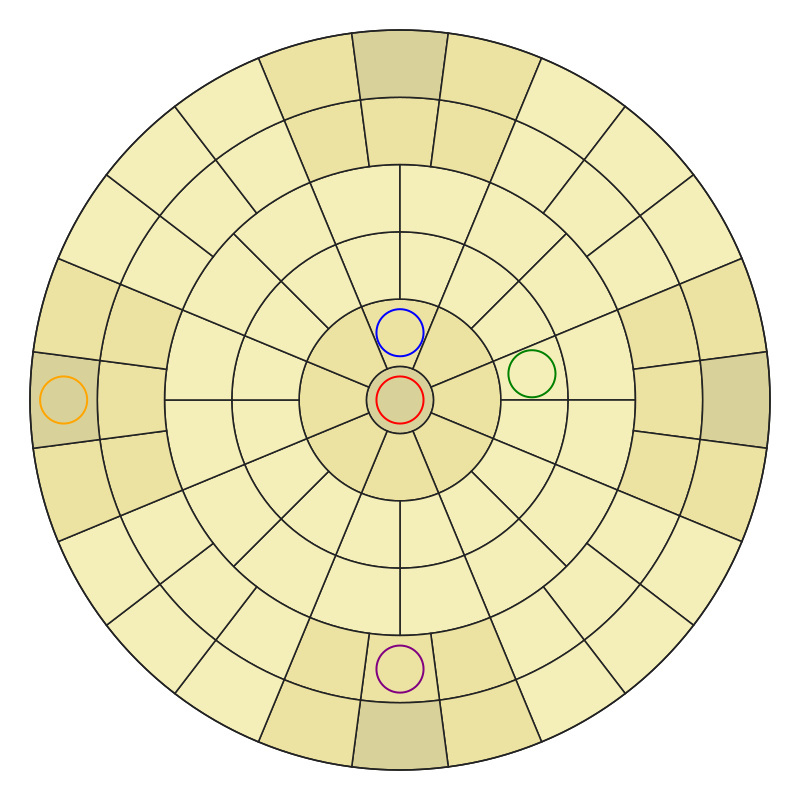

In [5]:
board = KaleidoBoardSVG(
    background_color="#ffffff",
    board_fill="#f4efb9",
    palace_fill="#ece2a2",
    home_fill="#d9d19a",
    board_stroke="#222222",
    board_size=800,
    stroke_width=1.6,
    margin=30,
)

extra = "\n".join([
    board.draw_marker_circle("00", fill="none", stroke="red", stroke_width=2),
    board.draw_marker_circle("1G", fill="none", stroke="blue", stroke_width=2),
    board.draw_marker_circle("3H", fill="none", stroke="green", stroke_width=2),
    board.draw_marker_circle("5A", fill="none", stroke="purple", stroke_width=2),
    board.draw_marker_circle("7B", fill="none", stroke="orange", stroke_width=2),
])

svg_text = board.render(extra_svg=extra)
display(SVG(svg_text))

In [6]:
import math
from IPython.display import SVG, display


class KaleidoBoardSVG:
    def __init__(
        self,
        background_color="#ffffff",
        board_fill="#f2edb8",
        palace_fill="#efe7aa",
        home_fill="#ddd59a",
        board_stroke="#222222",
        board_size=800,
        stroke_width=2.0,
        margin=40,
    ):
        self.background_color = background_color
        self.board_fill = board_fill
        self.palace_fill = palace_fill
        self.home_fill = home_fill
        self.board_stroke = board_stroke
        self.board_size = board_size
        self.stroke_width = stroke_width
        self.margin = margin

        self.cx = board_size / 2
        self.cy = board_size / 2

        # 링 경계: 0번째 링 반지름 0.5, 이후 1씩 증가
        self.r_boundaries = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

        # 각 링의 분할 수
        self.ring_sectors = {
            1: 8,
            2: 16,
            3: 16,
            4: 24,
            5: 24,
        }

        self.max_r = self.r_boundaries[-1]
        self.scale = (board_size / 2 - margin) / self.max_r

        # 원 게임과 각도 맞추기
        self.rotation_offset_deg = -22.5

        # 궁성
        self.palace_cells = {
            (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7),
            (4, 0), (4, 1), (4, 2), (5, 0), (5, 2),
            (4, 6), (4, 7), (4, 8), (5, 6), (5, 8),
            (4, 12), (4, 13), (4, 14), (5, 12), (5, 14),
            (4, 18), (4, 19), (4, 20), (5, 18), (5, 20)
        }

        # 홈칸 4개 + 중앙
        self.home_cells = {
            (5, 1),
            (5, 7),
            (5, 13),
            (5, 19),
        }

        # 좌표 문자 -> 링 / local index
        self.letter_to_ring_local = {
            "G": (1, 0),
            "H": (2, 0), "F": (2, 1),
            "I": (3, 0), "E": (3, 1),
            "J": (4, 0), "A": (4, 1), "D": (4, 2),
            "K": (5, 0), "B": (5, 1), "C": (5, 2),
        }

        self.ring_to_letters = {
            1: ["G"],
            2: ["H", "F"],
            3: ["I", "E"],
            4: ["J", "A", "D"],
            5: ["K", "B", "C"],
        }

    # -------------------------
    # 기본 기하
    # -------------------------
    def scaled_r(self, r):
        return r * self.scale

    def polar_to_cart(self, r, deg):
        rad = math.radians(deg)
        rr = self.scaled_r(r)
        x = self.cx + rr * math.cos(rad)
        y = self.cy + rr * math.sin(rad)
        return x, y

    def svg_header(self):
        s = self.board_size
        return (
            f'<svg xmlns="http://www.w3.org/2000/svg" '
            f'width="{s}" height="{s}" viewBox="0 0 {s} {s}">'
        )

    def svg_background(self):
        s = self.board_size
        return f'<rect x="0" y="0" width="{s}" height="{s}" fill="{self.background_color}" />'

    def outer_border(self):
        outer_r = self.scaled_r(self.max_r)
        return (
            f'<circle cx="{self.cx}" cy="{self.cy}" r="{outer_r}" '
            f'fill="none" stroke="{self.board_stroke}" '
            f'stroke-width="{self.stroke_width}" />'
        )

    def annular_sector_path(self, r_in, r_out, a0, a1):
        x1, y1 = self.polar_to_cart(r_in, a0)
        x2, y2 = self.polar_to_cart(r_out, a0)
        x3, y3 = self.polar_to_cart(r_out, a1)
        x4, y4 = self.polar_to_cart(r_in, a1)

        large_arc = 1 if ((a1 - a0) % 360) > 180 else 0
        r_out_px = self.scaled_r(r_out)
        r_in_px = self.scaled_r(r_in)

        return (
            f"M {x1:.4f},{y1:.4f} "
            f"L {x2:.4f},{y2:.4f} "
            f"A {r_out_px:.4f},{r_out_px:.4f} 0 {large_arc} 1 {x3:.4f},{y3:.4f} "
            f"L {x4:.4f},{y4:.4f} "
            f"A {r_in_px:.4f},{r_in_px:.4f} 0 {large_arc} 0 {x1:.4f},{y1:.4f} Z"
        )

    def cell_fill(self, ring_index=None, sector=None, is_center=False):
        if is_center:
            return self.home_fill
        if (ring_index, sector) in self.home_cells:
            return self.home_fill
        if (ring_index, sector) in self.palace_cells:
            return self.palace_fill
        return self.board_fill

    def draw_center_cell(self):
        r = self.scaled_r(self.r_boundaries[0])
        fill = self.cell_fill(is_center=True)
        return (
            f'<circle cx="{self.cx}" cy="{self.cy}" r="{r}" '
            f'fill="{fill}" stroke="{self.board_stroke}" '
            f'stroke-width="{self.stroke_width}" />'
        )

    def draw_ring_cells(self, ring_index, start_angle=-90):
        n = self.ring_sectors[ring_index]
        r_in = self.r_boundaries[ring_index - 1]
        r_out = self.r_boundaries[ring_index]
        angle_step = 360 / n

        parts = []
        for sector in range(n):
            a0 = start_angle + self.rotation_offset_deg + sector * angle_step
            a1 = a0 + angle_step
            d = self.annular_sector_path(r_in, r_out, a0, a1)
            fill = self.cell_fill(ring_index, sector)

            parts.append(
                f'<path d="{d}" fill="{fill}" '
                f'stroke="{self.board_stroke}" '
                f'stroke-width="{self.stroke_width}" />'
            )
        return "\n".join(parts)

    # -------------------------
    # 좌표 변환
    # -------------------------
    def label_to_ring_sector(self, label: str):
        label = label.strip().upper()
        if label == "00":
            return (0, 0)

        number = int(label[0])
        letter = label[1]

        ring, local = self.letter_to_ring_local[letter]
        group_size = len(self.ring_to_letters[ring])
        sector = (number - 1) * group_size + local
        return ring, sector

    def cell_center_polar(self, label: str):
        """
        중심은 반지름 0,1,2,3,4,5 지점.
        각도도 해당칸의 중앙.
        """
        label = label.strip().upper()

        if label == "00":
            return 0.0, 0.0

        number = int(label[0])
        letter = label[1]

        ring, local = self.letter_to_ring_local[letter]
        group_size = len(self.ring_to_letters[ring])

        r_center = float(ring)

        # 숫자 슬라이스 중심각
        slice_center_deg = -90 + self.rotation_offset_deg + (number - 1) * 45

        # 슬라이스 내부 local 중심각
        if group_size == 1:
            angle_offset = 22.5
        else:
            local_angle_step = 45 / group_size
            angle_offset = (local + 0.5) * local_angle_step 

        angle_deg = slice_center_deg + angle_offset
        return r_center, angle_deg

    def cell_center_xy(self, label: str):
        r, deg = self.cell_center_polar(label)
        return self.polar_to_cart(r, deg)

    def all_labels(self):
        labels = ["00"]
        for n in range(1, 9):
            for ch in ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K"]:
                labels.append(f"{n}{ch}")
        return labels

    # -------------------------
    # 셀 내부 텍스트
    # -------------------------
    def draw_cell_label(
        self,
        label: str,
        text=None,
        font_size=16,
        fill="#000000",
        font_weight="normal",
        dy=0.35,
    ):
        if text is None:
            text = label

        x, y = self.cell_center_xy(label)
        return (
            f'<text x="{x:.4f}" y="{y:.4f}" '
            f'font-size="{font_size}" fill="{fill}" font-weight="{font_weight}" '
            f'text-anchor="middle" dominant-baseline="middle" '
            f'font-family="serif" dy="{dy}">'
            f'{text}</text>'
        )

    def draw_all_labels(
        self,
        font_size=16,
        fill="#000000",
        font_weight="normal",
    ):
        parts = []
        parts.append(self.draw_cell_label("00", text="00", font_size=font_size, fill=fill, font_weight=font_weight))
        for n in range(1, 9):
            for ch in ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K"]:
                label = f"{n}{ch}"
                parts.append(
                    self.draw_cell_label(
                        label,
                        text=label,
                        font_size=font_size,
                        fill=fill,
                        font_weight=font_weight,
                    )
                )
        return "\n".join(parts)

    # -------------------------
    # 보조: 마커 원
    # -------------------------
    def draw_marker_circle(
        self,
        label: str,
        fill="none",
        stroke="#000000",
        stroke_width=None,
        radius=0.35,
        opacity=1.0,
    ):
        if stroke_width is None:
            stroke_width = self.stroke_width

        x, y = self.cell_center_xy(label)
        r_px = self.scaled_r(radius)

        return (
            f'<circle cx="{x:.4f}" cy="{y:.4f}" r="{r_px:.4f}" '
            f'fill="{fill}" stroke="{stroke}" '
            f'stroke-width="{stroke_width}" opacity="{opacity}" />'
        )

    # -------------------------
    # 기물 정규화
    # -------------------------
    def normalize_piece(self, piece: str):
        piece = piece.strip().upper()
        valid = {
            "X1", "X2", "X3", "X4",
            "Y1", "Y2", "Y3", "Y4",
            "Z1", "Z2", "Z3", "Z4",
        }
        if piece not in valid:
            raise ValueError(f"Invalid piece: {piece}")
        if piece == "Z1":
            return "Y1"
        return piece

    # -------------------------
    # 기물 내부 도형들
    # -------------------------
    def _dot_positions(self, n, spacing):
        if n == 1:
            return [(0, 0)]
        if n == 2:
            return [(0, -spacing * 0.65), (0, spacing * 0.65)]
        if n == 3:
            return [(0, -spacing), (-spacing * 0.85, spacing * 0.55), (spacing * 0.85, spacing * 0.55)]
        if n == 4:
            return [(-spacing, -spacing), (spacing, -spacing), (-spacing, spacing), (spacing, spacing)]
        raise ValueError("dot count must be 1..4")

    def _draw_x_piece_inner(self, grade, color, dot_radius=4.6):
        parts = []
        spacing = 6.5

        for dx, dy in self._dot_positions(grade, spacing):
            parts.append(
                f'<circle cx="{dx:.3f}" cy="{dy:.3f}" r="{dot_radius:.3f}" '
                f'fill="{color}" stroke="none" />'
            )
        return "\n".join(parts)

    def _draw_y_piece_inner_basic(self, grade, color):
        parts = []
        h = 18
        gap = 5.5
        offsets = {
            1: [0],
            2: [-gap/2, gap/2],
            3: [-gap, 0, gap],
            4: [-1.5*gap, -0.5*gap, 0.5*gap, 1.5*gap],
        }[grade]

        for dx in offsets:
            parts.append(
                f'<line x1="{dx:.3f}" y1="{-h/2:.3f}" x2="{dx:.3f}" y2="{h/2:.3f}" '
                f'stroke="{color}" stroke-width="2.2" stroke-linecap="round" />'
            )
        return "\n".join(parts)

    def _draw_y_piece_inner_readable(self, grade, color):
        if grade == 1:
            return self._draw_y_piece_inner_basic(1, color)

        if grade == 2:
            return "\n".join([
                f'<line x1="-7" y1="-7" x2="7" y2="7" stroke="{color}" stroke-width="2.4" stroke-linecap="round" />',
                f'<line x1="-7" y1="7" x2="7" y2="-7" stroke="{color}" stroke-width="2.4" stroke-linecap="round" />',
            ])

        if grade == 3:
            return self._draw_y_piece_inner_basic(3, color)

        if grade == 4:
            return "\n".join([
                f'<line x1="-7" y1="-9" x2="-7" y2="9" stroke="{color}" stroke-width="2.2" stroke-linecap="round" />',
                f'<line x1="7" y1="-9" x2="7" y2="9" stroke="{color}" stroke-width="2.2" stroke-linecap="round" />',
                f'<line x1="-9" y1="-7" x2="9" y2="-7" stroke="{color}" stroke-width="2.2" stroke-linecap="round" />',
                f'<line x1="-9" y1="7" x2="9" y2="7" stroke="{color}" stroke-width="2.2" stroke-linecap="round" />',
            ])

        raise ValueError("line grade must be 1..4")

    def _draw_z_piece_inner(self, grade, color):
        if grade == 2:
            # 아래변 없는 삼각형
            return "\n".join([
                f'<line x1="0" y1="-10" x2="-9" y2="7" stroke="{color}" stroke-width="2.4" stroke-linecap="round" />',
                f'<line x1="0" y1="-10" x2="9" y2="7" stroke="{color}" stroke-width="2.4" stroke-linecap="round" />',
            ])

        if grade == 3:
            # 삼각형
            pts = "0,-10 -9,7 9,7"
            return f'<polygon points="{pts}" fill="none" stroke="{color}" stroke-width="2.4" stroke-linejoin="round" />'

        if grade == 4:
            # 팔방위표 느낌
            parts = []
            lines = [
                ((0, -10), (0, 10)),
                ((-10, 0), (10, 0)),
                ((-7.2, -7.2), (7.2, 7.2)),
                ((-7.2, 7.2), (7.2, -7.2)),
            ]
            for (x1, y1), (x2, y2) in lines:
                parts.append(
                    f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" '
                    f'stroke="{color}" stroke-width="2.2" stroke-linecap="round" />'
                )
            return "\n".join(parts)

        raise ValueError("Z piece grade must be 2..4")

    # -------------------------
    # 기물 그리기
    # -------------------------
    def draw_piece(
        self,
        piece: str,
        label: str,
        color="#000000",
        outline_color=None,
        piece_radius=0.35,
        mode="basic",
        fill_circle=True,
        circle_fill="#ffffff",
        stroke_width=None,
    ):
        piece = self.normalize_piece(piece)

        if stroke_width is None:
            stroke_width = self.stroke_width

        if outline_color is None:
            outline_color = color

        x, y = self.cell_center_xy(label)
        outer_r_px = self.scaled_r(piece_radius)

        kind = piece[0]
        grade = int(piece[1])

        parts = [f'<g transform="translate({x:.4f},{y:.4f})">']

        # 바탕 원
        if fill_circle:
            parts.append(
                f'<circle cx="0" cy="0" r="{outer_r_px:.4f}" '
                f'fill="{circle_fill}" stroke="{outline_color}" '
                f'stroke-width="{stroke_width}" />'
            )
        else:
            parts.append(
                f'<circle cx="0" cy="0" r="{outer_r_px:.4f}" '
                f'fill="none" stroke="{outline_color}" '
                f'stroke-width="{stroke_width}" />'
            )

        # 내부 기호
        if kind == "X":
            parts.append(self._draw_x_piece_inner(grade, color))
        elif kind == "Y":
            if mode == "basic":
                parts.append(self._draw_y_piece_inner_basic(grade, color))
            elif mode == "readable":
                parts.append(self._draw_y_piece_inner_readable(grade, color))
            else:
                raise ValueError("mode must be 'basic' or 'readable'")
        elif kind == "Z":
            parts.append(self._draw_z_piece_inner(grade, color))
        else:
            raise ValueError(f"Unknown piece kind: {kind}")

        parts.append("</g>")
        return "\n".join(parts)

    # -------------------------
    # 렌더
    # -------------------------
    def render(self, extra_svg=""):
        parts = [
            self.svg_header(),
            self.svg_background(),
            '<g id="board-cells">',
            self.draw_center_cell(),
        ]

        for ring_index in range(1, 6):
            parts.append(self.draw_ring_cells(ring_index))

        parts += [
            "</g>",
            '<g id="board-border">',
            self.outer_border(),
            "</g>",
        ]

        if extra_svg:
            parts += ['<g id="extra">', extra_svg, '</g>']

        parts += ["</svg>"]
        return "\n".join(parts)

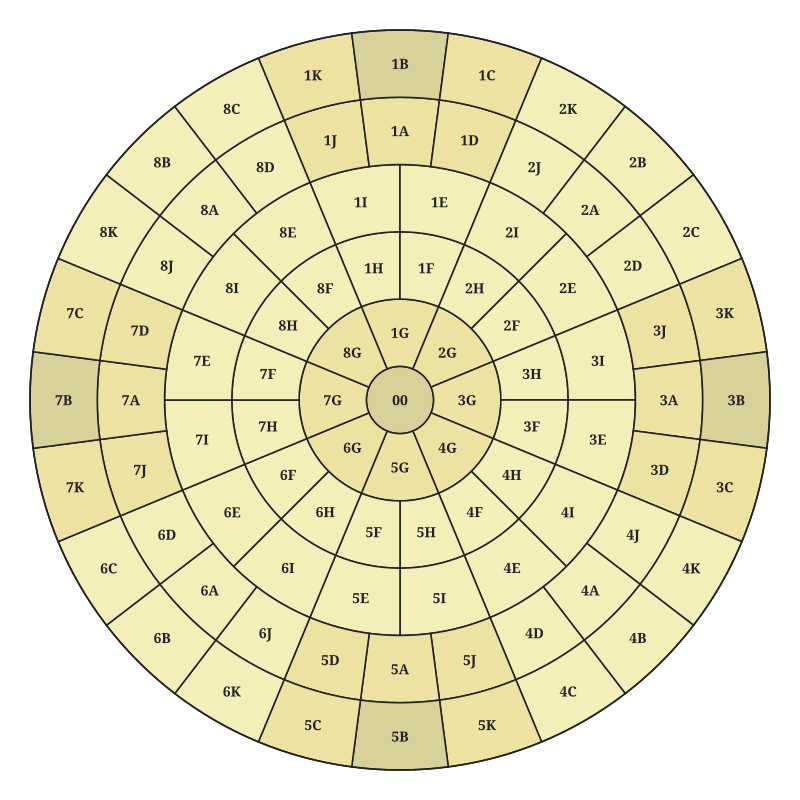

In [7]:
board = KaleidoBoardSVG(
    background_color="#ffffff",
    board_fill="#f4efb9",
    palace_fill="#ece2a2",
    home_fill="#d9d19a",
    board_stroke="#222222",
    board_size=800,
    stroke_width=1.6,
    margin=30,
)

extra = board.draw_all_labels(font_size=14, fill="#222222", font_weight="bold")
svg_text = board.render(extra_svg=extra)
display(SVG(svg_text))

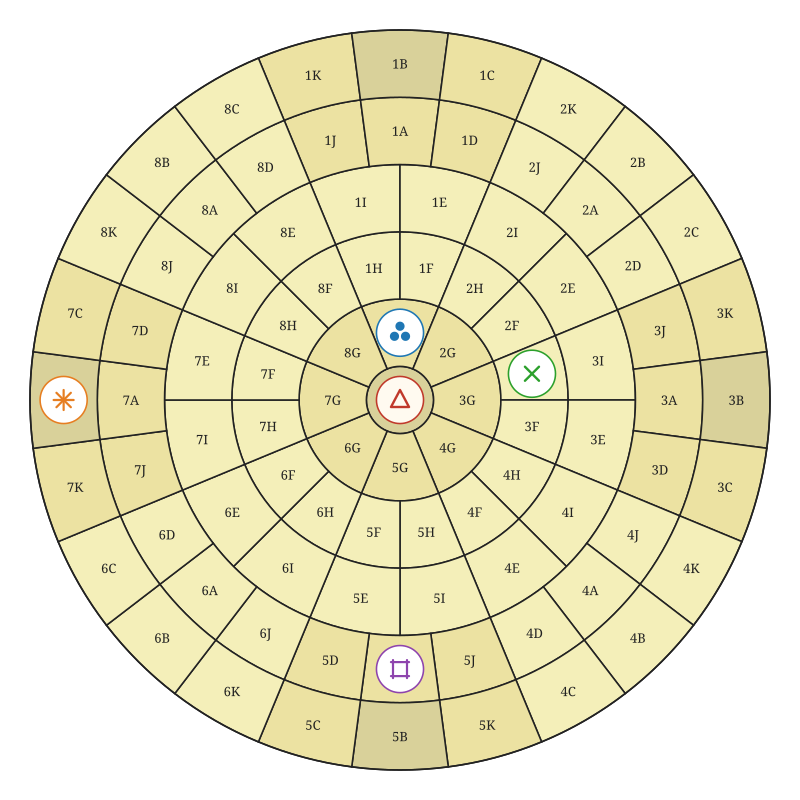

In [8]:
extra = "\n".join([
    board.draw_all_labels(font_size=13, fill="#222222"),

    board.draw_piece("Z3", "00", color="#c0392b", circle_fill="#fffaf0", mode="basic"),
    board.draw_piece("X3", "1G", color="#1f77b4", circle_fill="#ffffff"),
    board.draw_piece("Y2", "3H", color="#2ca02c", circle_fill="#ffffff", mode="readable"),
    board.draw_piece("Y4", "5A", color="#8e44ad", circle_fill="#ffffff", mode="readable"),
    board.draw_piece("Z4", "7B", color="#e67e22", circle_fill="#ffffff"),
])
svg_text = board.render(extra_svg=extra)
display(SVG(svg_text))

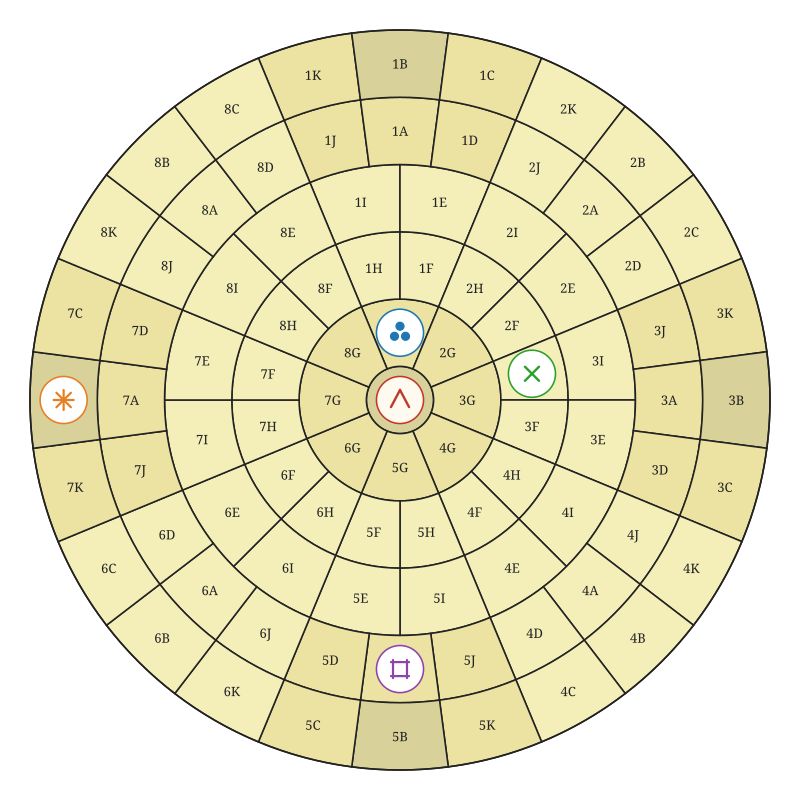

In [9]:
extra = "\n".join([
    board.draw_all_labels(font_size=13, fill="#222222"),

    board.draw_piece("Z2", "00", color="#c0392b", circle_fill="#fffaf0", mode="basic"),
    board.draw_piece("X3", "1G", color="#1f77b4", circle_fill="#ffffff"),
    board.draw_piece("Y2", "3H", color="#2ca02c", circle_fill="#ffffff", mode="readable"),
    board.draw_piece("Y4", "5A", color="#8e44ad", circle_fill="#ffffff", mode="readable"),
    board.draw_piece("Z4", "7B", color="#e67e22", circle_fill="#ffffff"),
])
svg_text = board.render(extra_svg=extra)
display(SVG(svg_text))

In [10]:
piece_code_to_name = {
    "X1": "pawn",
    "X2": "horse",
    "X3": "tiger",
    "X4": "elephant",
    "Y1": "raven",
    "Y2": "eagle",
    "Y3": "roc",
    "Y4": "dragon",
    "Z2": "fairy",
    "Z3": "wizard",
    "Z4": "magus",
}
piece_name_to_code = {
    "pawn": "X1",
    "horse": "X2",
    "tiger": "X3",
    "elephant": "X4",
    "raven": "Y1",
    "eagle": "Y2",
    "roc": "Y3",
    "dragon": "Y4",
    "fairy": "Z2",
    "wizard": "Z3",
    "magus": "Z4",
}

In [11]:
TEAM_STYLES = {
    "red":   {"color": "#e74c3c"},
    "pink":  {"color": "#ff00cc"},
    "blue":  {"color": "#4da3ff"},
    "green": {"color": "#2ca02c"},
    "olive": {"color": "#8a8f00"},
}

In [12]:
board_setup = {
    "Blue": {
        "pawn":     ["8A", "8D", "2J", "2A"],
        "horse":    ["8J", "2D"],
        "tiger":    ["8K", "2C"],
        "elephant": ["8C", "2K"],
        "roc":      ["1K", "1C"],
        "eagle":    ["2B", "8B"],
        "raven":    ["1D", "1J"],
        "dragon":   ["1A"],
        "wizard":   ["1B"],
    },
    "Orange": {
        "pawn":     ["4A", "4D", "6J", "6A"],
        "horse":    ["4J", "6D"],
        "tiger":    ["4K", "6C"],
        "elephant": ["4C", "6K"],
        "roc":      ["5K", "5C"],
        "eagle":    ["6B", "4B"],
        "raven":    ["5D", "5J"],
        "dragon":   ["5A"],
        "wizard":   ["5B"],
    },
}

In [13]:
team_styles = {
    "Blue": {
        "color": "#1f77b4",
        "circle_fill": "#ffffff",
    },
    "Orange": {
        "color": "#e67e22",
        "circle_fill": "#fffaf0",
    },
}

In [14]:
def flatten_board_setup(board_setup, piece_name_to_code):
    flat = []

    for team, pieces in board_setup.items():
        for piece_name, cells in pieces.items():
            piece_code = piece_name_to_code[piece_name]
            for cell in cells:
                flat.append({
                    "team": team,
                    "piece": piece_code,
                    "cell": cell,
                })

    return flat

In [15]:
def flatten_board_setup(board_setup, piece_name_to_code):
    flat = []

    for team, pieces in board_setup.items():
        for piece_name, cells in pieces.items():
            piece_code = piece_name_to_code[piece_name]
            for cell in cells:
                flat.append({
                    "team": team,
                    "piece": piece_code,
                    "cell": cell,
                })

    return flat

In [16]:
def render_setup_extra(
    board,
    board_setup,
    piece_name_to_code,
    team_styles,
    mode="basic",
    show_labels=True,
    label_font_size=13,
    label_fill="#222222",
):
    parts = []

    if show_labels:
        parts.append(
            board.draw_all_labels(
                font_size=label_font_size,
                fill=label_fill,
                font_weight="normal",
            )
        )

    flat = flatten_board_setup(board_setup, piece_name_to_code)

    for item in flat:
        team = item["team"]
        piece = item["piece"]
        cell = item["cell"]

        style = team_styles[team]

        parts.append(
            board.draw_piece(
                piece,
                cell,
                color=style["color"],
                circle_fill=style.get("circle_fill", "#ffffff"),
                mode=mode,
            )
        )

    return "\n".join(parts)

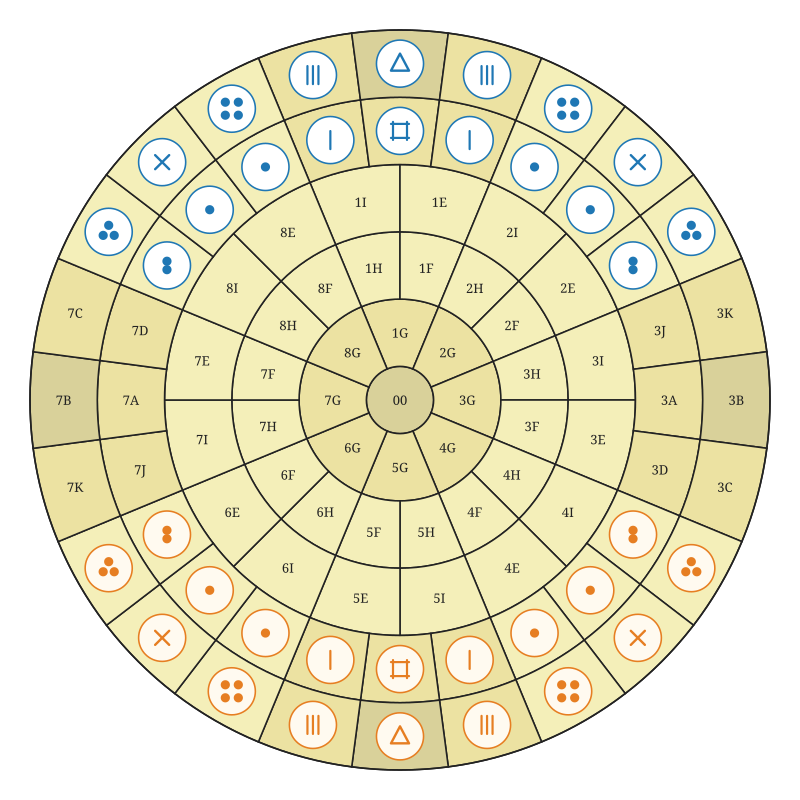

In [17]:
board = KaleidoBoardSVG(
    background_color="#ffffff",
    board_fill="#f4efb9",
    palace_fill="#ece2a2",
    home_fill="#d9d19a",
    board_stroke="#222222",
    board_size=800,
    stroke_width=1.6,
    margin=30,
)

piece_name_to_code = {
    "pawn": "X1",
    "horse": "X2",
    "tiger": "X3",
    "elephant": "X4",
    "raven": "Y1",
    "eagle": "Y2",
    "roc": "Y3",
    "dragon": "Y4",
    "fairy": "Z2",
    "wizard": "Z3",
    "magus": "Z4",
}

team_styles_2p = {
    "Blue": {
        "color": "#1f77b4",
        "circle_fill": "#ffffff",
    },
    "Orange": {
        "color": "#e67e22",
        "circle_fill": "#fffaf0",
    },
}

board_setup_2p = {
    "Blue": {
        "pawn":     ["8A", "8D", "2J", "2A"],
        "horse":    ["8J", "2D"],
        "tiger":    ["8K", "2C"],
        "elephant": ["8C", "2K"],
        "roc":      ["1K", "1C"],
        "eagle":    ["2B", "8B"],
        "raven":    ["1D", "1J"],
        "dragon":   ["1A"],
        "wizard":   ["1B"],
    },
    "Orange": {
        "pawn":     ["4A", "4D", "6J", "6A"],
        "horse":    ["4J", "6D"],
        "tiger":    ["4K", "6C"],
        "elephant": ["4C", "6K"],
        "roc":      ["5K", "5C"],
        "eagle":    ["6B", "4B"],
        "raven":    ["5D", "5J"],
        "dragon":   ["5A"],
        "wizard":   ["5B"],
    },
}

extra = render_setup_extra(
    board=board,
    board_setup=board_setup_2p,
    piece_name_to_code=piece_name_to_code,
    team_styles=team_styles_2p,
    mode="readable",   # 또는 "basic"
    show_labels=True,
    label_font_size=13,
)

svg_text = board.render(extra_svg=extra)
display(SVG(svg_text))

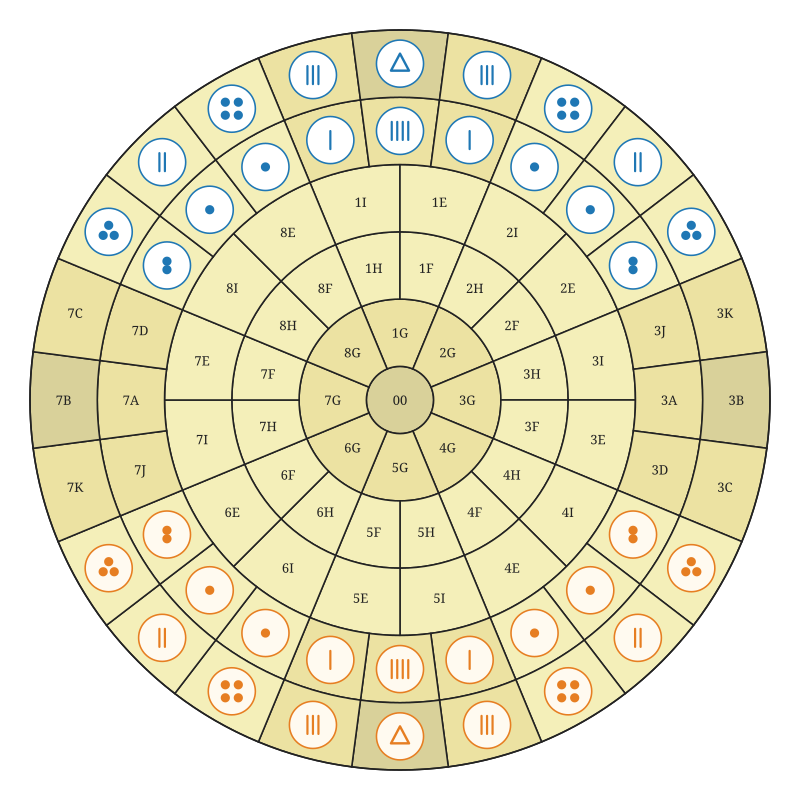

In [18]:

extra = render_setup_extra(
    board=board,
    board_setup=board_setup_2p,
    piece_name_to_code=piece_name_to_code,
    team_styles=team_styles_2p,
    mode="basic",   # 또는 "basic"
    show_labels=True,
    label_font_size=13,
)

svg_text = board.render(extra_svg=extra)
display(SVG(svg_text))

In [19]:
board_setup_3p = {
    "Blue": {
        "pawn":   ["8D", "1A", "2J"],
        "horse":  ["8A", "2A"],
        "tiger":  ["8C", "2K"],
        "roc":    ["1K", "1C"],
        "eagle":  ["2B", "8B"],
        "raven":  ["1D", "1J"],
        "wizard": ["1B"],
    },
    "Orange": {
        "pawn":   ["4D", "5A", "6J"],
        "horse":  ["4A", "6A"],
        "tiger":  ["4C", "6K"],
        "roc":    ["5K", "5C"],
        "eagle":  ["6B", "4B"],
        "raven":  ["5D", "5J"],
        "wizard": ["5B"],
    },
    "Green": {
        "pawn":   ["3F", "3H", "7F", "7H"],
        "horse":  ["2G", "6G"],
        "tiger":  ["4G", "8G"],
        "roc":    ["3G", "7G"],
        "eagle":  ["1G", "5G"],
        "raven":  ["3E", "7E"],
        "wizard": ["00"],   # OO -> 00 정규화
    },
}

In [20]:
team_styles_3p = {
    "Blue": {
        "color": "#1f77b4",
        "circle_fill": "#ffffff",
    },
    "Orange": {
        "color": "#e67e22",
        "circle_fill": "#fffaf0",
    },
    "Green": {
        "color": "#2ca02c",
        "circle_fill": "#f8fff8",
    },
}

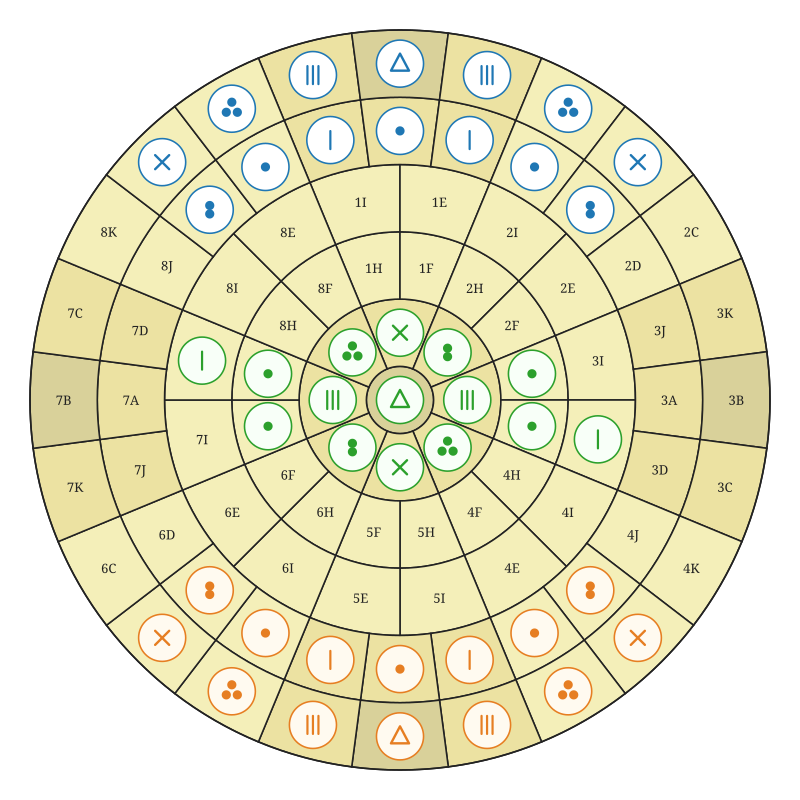

In [21]:

extra = render_setup_extra(
    board=board,
    board_setup=board_setup_3p,
    piece_name_to_code=piece_name_to_code,
    team_styles=team_styles_3p,
    mode="readable",   # 또는 "basic"
    show_labels=True,
    label_font_size=13,
)

svg_text = board.render(extra_svg=extra)
display(SVG(svg_text))

In [22]:
board_setup_4p = {
    "Blue": {
        "pawn":   ["8C", "8D", "2J", "2K"],
        "horse":  ["1E", "1I"],
        "tiger":  ["1D", "1J"],
        "roc":    ["1C", "1K"],
        "dragon": ["1A"],
        "wizard": ["1B"],
    },
    "Green": {
        "pawn":   ["2C", "2D", "4J", "4K"],
        "horse":  ["3E", "3I"],
        "tiger":  ["3D", "3J"],
        "roc":    ["3C", "3K"],
        "dragon": ["3A"],
        "wizard": ["3B"],
    },
    "Orange": {
        "pawn":   ["4C", "4D", "6J", "6K"],
        "horse":  ["5E", "5I"],
        "tiger":  ["5D", "5J"],
        "roc":    ["5C", "5K"],
        "dragon": ["5A"],
        "wizard": ["5B"],
    },
    "Pink": {
        "pawn":   ["6C", "6D", "8J", "8K"],
        "horse":  ["7E", "7I"],
        "tiger":  ["7D", "7J"],
        "roc":    ["7C", "7K"],
        "dragon": ["7A"],
        "wizard": ["7B"],
    },
}

In [23]:
team_styles_4p = {
    "Blue": {
        "color": "#1f77b4",
        "circle_fill": "#ffffff",
    },
    "Green": {
        "color": "#2ca02c",
        "circle_fill": "#f8fff8",
    },
    "Orange": {
        "color": "#e67e22",
        "circle_fill": "#fffaf0",
    },
    "Pink": {
        "color": "#e83e8c",
        "circle_fill": "#fff7fb",
    },
}

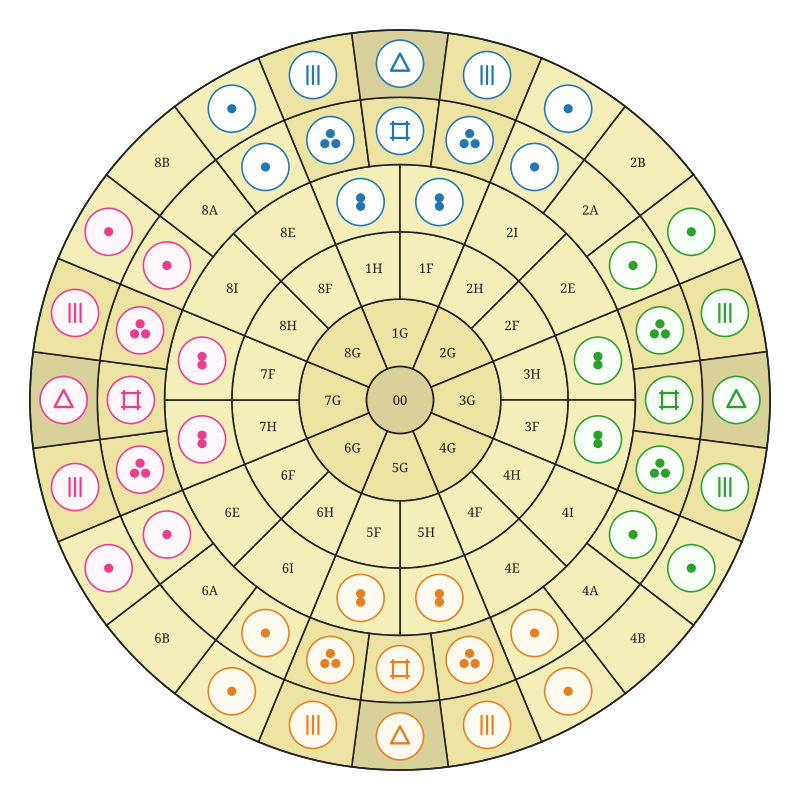

In [24]:
extra = render_setup_extra(
    board=board,
    board_setup=board_setup_4p,
    piece_name_to_code=piece_name_to_code,
    team_styles=team_styles_4p,
    mode="readable",
    show_labels=True,
    label_font_size=13,
)

svg_text = board.render(extra_svg=extra)
display(SVG(svg_text))

In [25]:
board_setup_5p = {
    "Blue": {
        "pawn":   ["2I"],
        "horse":  ["1E", "1I"],
        "tiger":  ["1D", "1J"],
        "roc":    ["1A"],
        "eagle":  ["1C", "1K"],
        "raven":  ["8E"],
        "wizard": ["1B"],
    },
    "Green": {
        "pawn":   ["3I"],
        "horse":  ["2D", "4J"],
        "tiger":  ["3D", "3J"],
        "roc":    ["3A"],
        "eagle":  ["3C", "3K"],
        "raven":  ["3E"],
        "wizard": ["3B"],
    },
    "Orange": {
        "pawn":   ["6I"],
        "horse":  ["5E", "5I"],
        "tiger":  ["5D", "5J"],
        "roc":    ["5A"],
        "eagle":  ["5C", "5K"],
        "raven":  ["4E"],
        "wizard": ["5B"],
    },
    "Pink": {
        "pawn":   ["7I"],
        "horse":  ["6D", "8J"],
        "tiger":  ["7D", "7J"],
        "roc":    ["7A"],
        "eagle":  ["7C", "7K"],
        "raven":  ["7E"],
        "wizard": ["7B"],
    },
    "Yellow": {
        "pawn":   ["4H", "8H"],
        "horse":  ["2F", "6F"],
        "tiger":  ["4G", "8G"],
        "eagle":  ["1G", "3G", "5G", "7G"],
        "wizard": ["00"],   # OO → 00
    },
}
team_styles_5p = {
    "Blue": {
        "color": "#1f77b4",
        "circle_fill": "#ffffff",
    },
    "Green": {
        "color": "#2ca02c",
        "circle_fill": "#f8fff8",
    },
    "Orange": {
        "color": "#e67e22",
        "circle_fill": "#fffaf0",
    },
    "Pink": {
        "color": "#e83e8c",
        "circle_fill": "#fff7fb",
    },
    "Yellow": {
        "color": "#d4a017",
        "circle_fill": "#fffde7",
    },
}

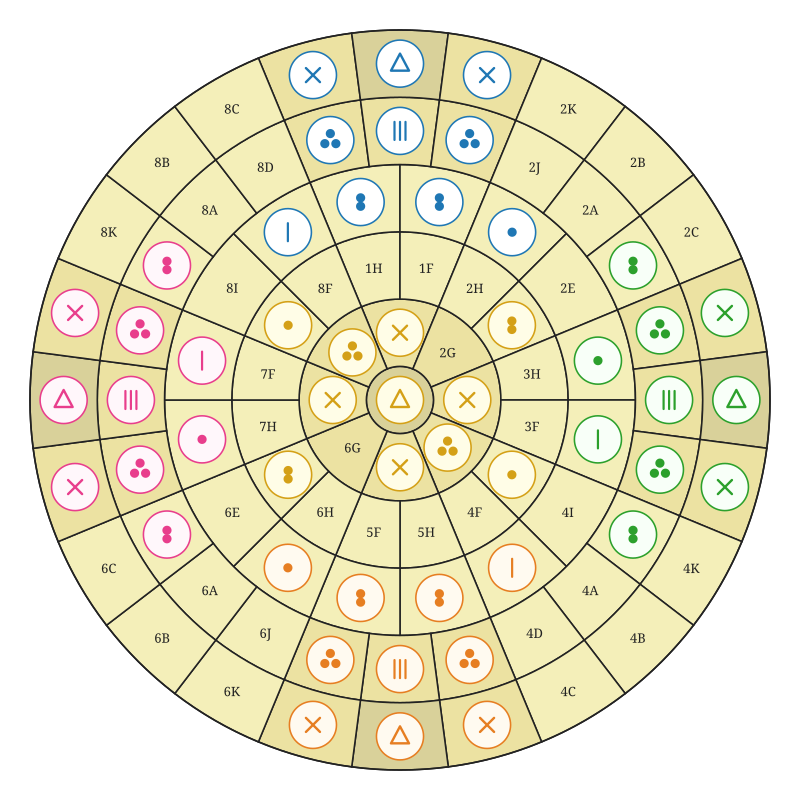

In [26]:
extra = render_setup_extra(
    board=board,
    board_setup=board_setup_5p,
    piece_name_to_code=piece_name_to_code,
    team_styles=team_styles_5p,
    mode="readable",
    show_labels=True,
    label_font_size=13,
)

svg_text = board.render(extra_svg=extra)
display(SVG(svg_text))

In [27]:
ALL_SETUPS = {
    2: board_setup_2p,
    3: board_setup_3p,
    4: board_setup_4p,
    5: board_setup_5p,
}
def get_setup(players):
    return ALL_SETUPS[players]

In [59]:
extra = render_setup_extra(
    board,
    get_setup(2),
    piece_name_to_code,
    team_styles_5p,
    mode="readable"
)

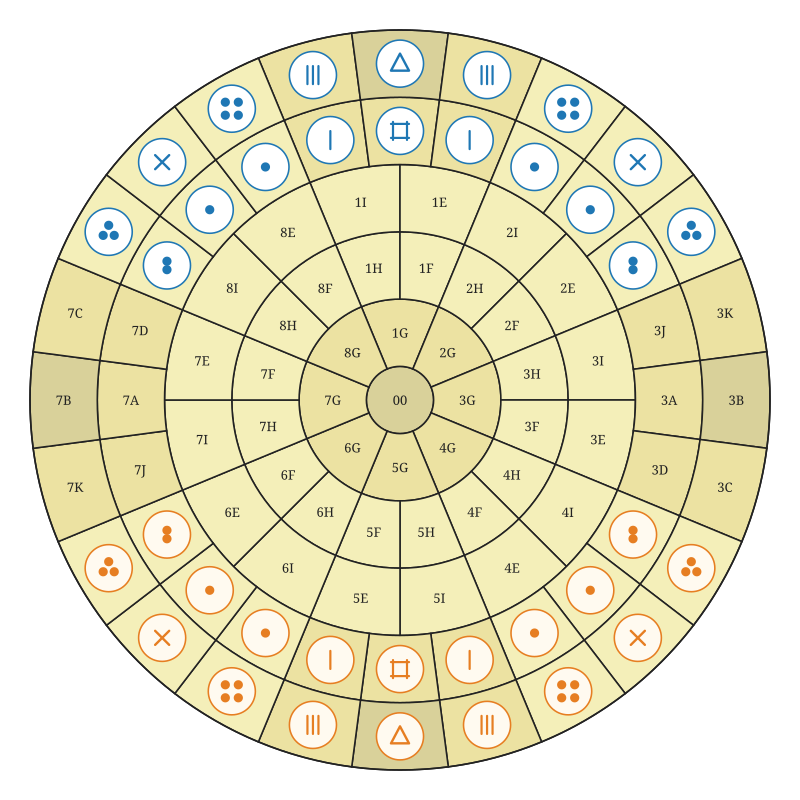

In [61]:
svg_text = board.render(extra_svg=extra)
display(SVG(svg_text))